# Calcular area con titulo minero
- La ANM publica la base de datos de títulos mineros identificando el municipio correspondiente y el mineral que se explota https://www.datos.gov.co/Minas-y-Energ-a/ANM-RUCOM-Explotador-Minero-Autorizado-T-tulo-Mine/42ha-fhvj/about_data
- El problema es que no publica directamente el área de cada título minero ni los polígonos
- Sin embargo, si se conoce el número del expediente del título minero, los polígonos se pueden descargar del visor de la ANM https://annamineria.anm.gov.co/Html5Viewer/index.html?viewer=SIGMExt&locale=es-CO&appAcronym=sigm
- El video de esta página es una guía de la ANM de cómo hacerlo https://www.anm.gov.co/ventanilla-minera
- El problema es que descargarlos manualmente es demasiado extenso y suceptible a errores porque es un alto número de polígonos. Sólo para el oro son alrededor de 270 polígonos.
- Encontré una forma de importar los políginos con un punto de acceso al servidor de arcgis. 
- La idea es replicar queries como este que devulven una respuesta en json https://annamineria.anm.gov.co/annageo/rest/services/SIGM/TenureLayers/MapServer/4/query?f=json&where=LOWER(CODIGO_EXPEDIENTE)%20LIKE%20%27%25abq-101%25%27&returnGeometry=true&spatialRel=esriSpatialRelIntersects&outFields=*&outSR=102100https://annamineria.anm.gov.co/annageo/rest/services/SIGM/TenureLayers/MapServer/4/query?f=json&where=LOWER(CODIGO_EXPEDIENTE)%20LIKE%20%27%25abq-101%25%27&returnGeometry=true&spatialRel=esriSpatialRelIntersects&outFields=*&outSR=102100
- Esa respuesta después se puede convertir en un geodataframe
- En este cuaderno hago el query respectivo para cada titulo minero de oro en la base de títulos mineros de la ANM

# Importar Paquetes

In [1]:
# Hacer queries a servidores
import requests 

# Manejar datos
import pandas as pd

# Manejar datos espaciales
import geopandas as gpd
from shapely.validation import make_valid

# Convertir Json a geopandas
#pip install arcgis2geojson geopandas shapely
from arcgis2geojson import arcgis2geojson

# Utilidades
from tqdm import tqdm # revisar avance de ciclos
import warnings # Manejar warnings

# Gráficas
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import seaborn as sns

# Ejemplo sencillo

In [2]:
# ruta de acceso
url = "https://annamineria.anm.gov.co/annageo/rest/services/SIGM/TenureLayers/MapServer/4/query"

# Parametros de la consulta
params = {
    "f": "json",
    "where": "CODIGO_EXPEDIENTE = 'ABQ-101'",
    "returnGeometry": "true",
    "outFields": "*",
    "outSR": "102100"
}

# Consultar
response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

# Explorar resultado
print(response.url)
print(response.status_code)
print(response.headers.get("content-type"))
print(response.text[:500])

# Convertir a json
data = response.json()
# Convertir ArcGIS JSON a GeoJSON
geojson_dict = arcgis2geojson(data)

# Pasar a GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(geojson_dict["features"])
# Asignar CRS con el que vienen los datos
gdf = gdf.set_crs(epsg=102100, allow_override=True)

Object converted in non-standard crs - {'wkid': 102100, 'latestWkid': 3857}


https://annamineria.anm.gov.co/annageo/rest/services/SIGM/TenureLayers/MapServer/4/query?f=json&where=CODIGO_EXPEDIENTE+%3D+%27ABQ-101%27&returnGeometry=true&outFields=%2A&outSR=102100
200
application/json;charset=UTF-8
{"displayFieldName":"CODIGO_EXPEDIENTE","fieldAliases":{"CODIGO_EXPEDIENTE":"CODIGO_EXPEDIENTE","MODALIDAD":"MODALIDAD","TITULO_ESTADO":"TITULO_ESTADO","AREA_HA":"AREA_HA","CLASIFICACION_MINERIA":"CLASIFICACION_MINERIA","ETAPA":"ETAPA","SOLICITANTES_O_TITULARES":"SOLICITANTES_O_TITULARES","MINERALES":"MINERALES","FECHA_DE_SOLICITUD":"FECHA_DE_SOLICITUD","FECHA_DE_EXPEDICION":"FECHA_DE_EXPEDICION","FECHA_DE_ANIVERSARIO":"FECHA_DE_ANIVERSARIO","FECHA_DE_EXPIRACION":"FECHA_DE_EXPIRACION","PUBLICADO


In [3]:
gdf.head()

,geometry,CODIGO_EXPEDIENTE,MODALIDAD,TITULO_ESTADO,AREA_HA,CLASIFICACION_MINERIA,ETAPA,SOLICITANTES_O_TITULARES,MINERALES,FECHA_DE_SOLICITUD,...,CENTROID_COORDINATE,TENURE_ID,OBJECTID,MUNICIPIOS,DEPARTAMENTOS,MINERALES_INACTIVOS,TIPO_TERMINACION,TERMINATION_TYPE_CODE,ACTIVE_TENURE_STATUS_IND,ACTIVE_APPLICATION_STATUS_IND
0,"POLYGON ((-8517471.673 397325.576, -8517471.29...",ABQ-101,CONTRATO DE CONCESIÓN (D 2655),Activo,39.0812,Mediana,Explotación,(61017) CANTERA LA EMILIA SAS,"DIABASA, RECEBO",920023200000,...,"-76.51667,3.56964",ABQ-101,176246,YUMBO,Valle del Cauca,None,None,None,Y,N


# Extraer poligonos de todos los proyectos de oro

## Obtener expedientes de los polígonos

In [4]:
# Cargar información de títutlos mineros
titulos_mineros = pd.read_excel('../../Data/5_ANM_datos_abiertos/ANM_RUCOM_Explotador_Minero_Autorizado-Título_Minero_20260404.xlsx')

# Extraer únicamente titulos mineros de minerales de oro
titulos_mineros_oro = titulos_mineros[titulos_mineros['MINERAL'].str.contains('ORO')]

# Extraer nombres de los expedientes de titulos oro
expedientes_oro = list(titulos_mineros_oro['CODIGO_EXPEDIENTE'].unique())

In [5]:
# Mostrar dimensión de los datos
print("\n"+"*"*20+" Títulos mineros por tipo de mineral")
display(titulos_mineros.drop_duplicates(subset='CODIGO_EXPEDIENTE')['MINERAL'].value_counts())
print("*** Total", titulos_mineros.drop_duplicates(subset='CODIGO_EXPEDIENTE').shape)

print("\n"+"*"*20+" Títulos mineros de oro")
display(titulos_mineros_oro.drop_duplicates(subset='CODIGO_EXPEDIENTE')['MINERAL'].value_counts())
print("*** Total", titulos_mineros_oro.drop_duplicates(subset='CODIGO_EXPEDIENTE')['MINERAL'].shape)


******************** Títulos mineros por tipo de mineral


MINERAL
MATERIALES DE CONSTRUCCION                                733
CARBON                                                    461
DEMAS_CONCESIBLES                                         212
ARCILLA                                                   196
MATERIALES DE CONSTRUCCIÓN                                178
                                                         ... 
ESMERALDAS SIN TALLAR                                       1
OTRAS ROCAS METAMÓRFICAS PARA CONSTRUCCIÓN Y TALLA NCP      1
FOSFORITA                                                   1
ÓXIDO DE MAGNESIO PURO                                      1
ARENISCAS (MIG)                                             1
Name: count, Length: 129, dtype: int64

*** Total (2807, 7)

******************** Títulos mineros de oro


MINERAL
ORO                                               171
MINERALES DE ORO Y SUS CONCENTRADOS                63
ORO VETA                                           15
MINERALES DE ORO Y PLATINO, Y SUS CONCENTRADOS     10
ORO ALUVION                                         8
ORO FILON                                           1
Name: count, dtype: int64

*** Total (268,)


## Obtener poligonos de cada expediente

In [6]:
# Omitir warning de CRS del que soy consciente
warnings.filterwarnings("ignore", message=".*non-standard crs.*")

<span style="color:red">
    El código de la siguiente celda es demorado y ya fue ejecutado. Guardé el resultado en un .parquet
    Entonces, no hace falta volver a ejecutarlo. Solo hay que cargar los datos que había guardado
</span>


In [89]:
# ruta de acceso
url = "https://annamineria.anm.gov.co/annageo/rest/services/SIGM/TenureLayers/MapServer/4/query"

# Lista para almacenar poligonos
gdfs = []

# Para cada expediente
for exp in tqdm(expedientes_oro):
    
    # Definir parametros de query
    params = {
        "f": "json",
        "where": f"CODIGO_EXPEDIENTE = '{exp}'",
        "returnGeometry": "true",
        "outFields": "*",
        "outSR": "102100" # En la versión del query original sale con 102100, pero esa no es una forma estandar de especficarlo
    }
    
    # Obtener respuesta
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()
    
    if data.get("features"): # Si la respuesta existe
        geojson_dict = arcgis2geojson(data)
        gdf_temp = gpd.GeoDataFrame.from_features(geojson_dict["features"])
        gdf_temp = gdf_temp.set_crs(epsg=102100, allow_override=True)
        gdfs.append(gdf_temp)

100%|████████████████████████████████████████████████████████████████████████████████| 268/268 [03:21<00:00,  1.33it/s]


In [95]:
# Organizar resultado final
gdf_final = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:102100")

# Exportar resultado
gdf_final.to_parquet("./outputs/titulos_oro.parquet")

C:\Users\jcalf\AppData\Local\Temp\ipykernel_37236\1264072311.py:6: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_final.to_file("./outputs/titulos_oro.shp")
C:\Users\jcalf\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'CODIGO_EXPEDIENTE' to 'CODIGO_EXP'
  ogr_write(
C:\Users\jcalf\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'TITULO_ESTADO' to 'TITULO_EST'
  ogr_write(
C:\Users\jcalf\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'CLASIFICACION_MINERIA' to 'CLASIFICAC'
  ogr_write(
C:\Users\jcalf\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'SOLICITANTES_O_TITULARES' to 'SOLICITANT'
  ogr_write(
C:\Users\jcalf\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'FECHA_DE_SOLICITUD' 

# Cargar resultado intermedio

In [100]:
# Exportar resultado intermedio
#gdf_final.to_excel("./outputs/titulos_oro.xlsx")

In [35]:
# Cargar resultado guardado
gdf_final = gpd.read_parquet("./outputs/titulos_oro.parquet")

## Procesar fechas de los datos

In [36]:
# Arreglar las fechas de los registros

# Lista de columnas que deberían tener fechas
columnas_fecha = ['FECHA_DE_SOLICITUD', 'FECHA_DE_EXPEDICION','FECHA_DE_ANIVERSARIO', 'FECHA_DE_EXPIRACION']

# Explorar las fechas de los registros
display(gdf_final[['CODIGO_EXPEDIENTE'] + columnas_fecha].head())

,CODIGO_EXPEDIENTE,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION
0,ARE-SCG-08001X,1489651200000,1559299512000,1559299512000,2.232576e+12
1,ARE-SCG-08011X,1489651261000,1559216693000,1559216693000,2.208730e+12
2,ARE-SKM-08001X,1511337600000,1662595200000,1662595200000,2.262125e+12
3,ARE-SKM-08011X,1511337660000,1631145600000,1631145600000,1.757290e+12
4,ARE-TB8-16011,1503446400000,1652400000000,1652400000000,2.283552e+12


In [37]:
# Convertir milisegundos a fechas
for col in columnas_fecha:
    s = pd.to_numeric(gdf_final[col], errors='coerce')
    
    gdf_final[col] = (
        pd.to_datetime(s, unit='ms', errors='coerce') # 18 títulos mineros tenían N/A en 'FECHA_DE_EXPIRACION'. Con esto mantengo el NA en lugar de mostrar errores
          # .dt.tz_convert('America/Bogota')
          # .dt.tz_localize(None)
    )

# Verificar fechas
display(gdf_final[['CODIGO_EXPEDIENTE'] + columnas_fecha].head())

,CODIGO_EXPEDIENTE,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION
0,ARE-SCG-08001X,2017-03-16 08:00:00,2019-05-31 10:45:12,2019-05-31 10:45:12,2040-09-30
1,ARE-SCG-08011X,2017-03-16 08:01:01,2019-05-30 11:44:53,2019-05-30 11:44:53,2039-12-29
2,ARE-SKM-08001X,2017-11-22 08:00:00,2022-09-08 00:00:00,2022-09-08 00:00:00,2041-09-07
3,ARE-SKM-08011X,2017-11-22 08:01:00,2021-09-09 00:00:00,2021-09-09 00:00:00,2025-09-08
4,ARE-TB8-16011,2017-08-23 00:00:00,2022-05-13 00:00:00,2022-05-13 00:00:00,2042-05-13


- La información de los títulos mineros se puede visualizar en [ANNA minería](https://annamineria.anm.gov.co/Html5Viewer/index.html?viewer=SIGMExt&locale=es-CO&appAcronym=sigm)
- La siguiente imágen es un recorte de la información para los títulos mineros de Expediente 'ARE-SCG-08001X' y 'ARE-SKM-08001X'
- La verificación es que el valor que consigo en el dataframe es el mismo que se reporta en el visor de la ANM

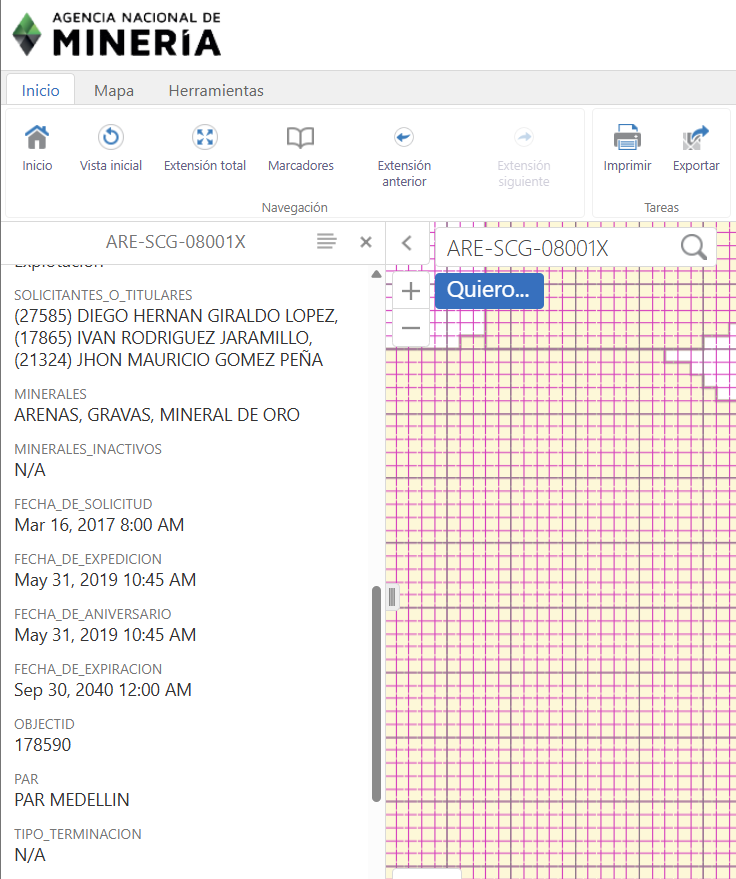 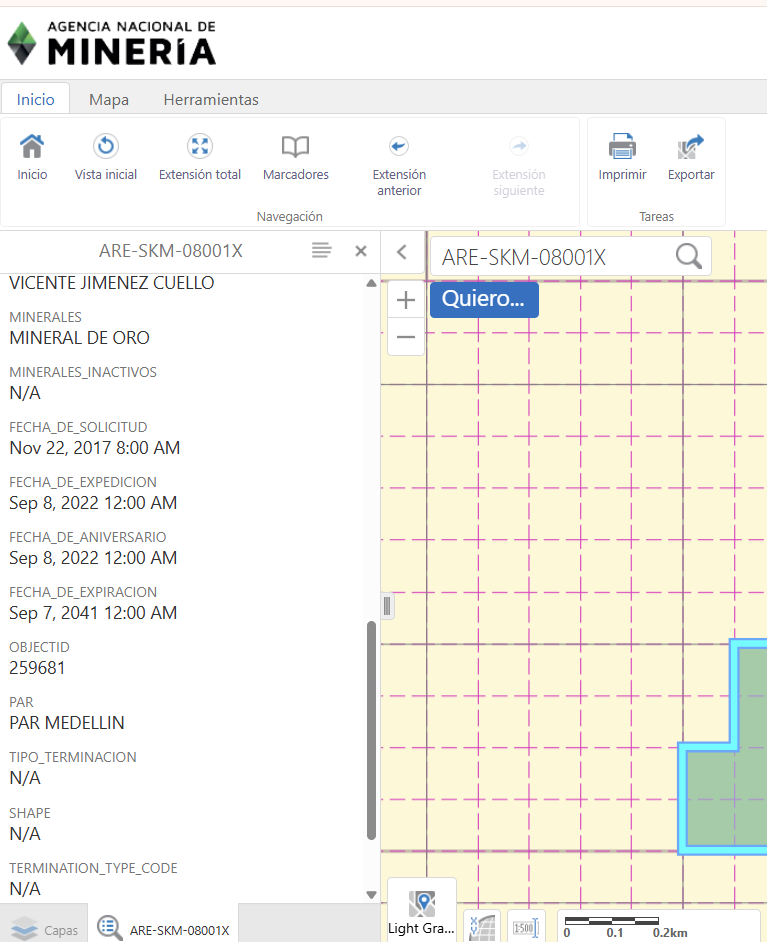

# Explorar otras variables de los datos
En esta sección hago gráficas rápidas para explorar los datos cualitativamente

In [38]:
gdf_final.columns

Index(['geometry', 'CODIGO_EXPEDIENTE', 'MODALIDAD', 'TITULO_ESTADO',
       'AREA_HA', 'CLASIFICACION_MINERIA', 'ETAPA', 'SOLICITANTES_O_TITULARES',
       'MINERALES', 'FECHA_DE_SOLICITUD', 'FECHA_DE_EXPEDICION',
       'FECHA_DE_ANIVERSARIO', 'FECHA_DE_EXPIRACION', 'PUBLICADO_EN_RUCOM',
       'PAR', 'TITLE_TYPE_CODE', 'TENURE_STATUS_CODE',
       'MINING_CLASSIFICATION_CODE', 'TENURE_STAGE_CODE',
       'CENTROID_COORDINATE', 'TENURE_ID', 'OBJECTID', 'MUNICIPIOS',
       'DEPARTAMENTOS', 'MINERALES_INACTIVOS', 'TIPO_TERMINACION',
       'TERMINATION_TYPE_CODE', 'ACTIVE_TENURE_STATUS_IND',
       'ACTIVE_APPLICATION_STATUS_IND'],
      dtype='object')

In [40]:
gdf_final['ETAPA'].value_counts()

ETAPA
Explotación    264
Exploración      4
Name: count, dtype: int64

In [41]:
data = gdf_final.copy()
data['anno_solicitud'] = data['FECHA_DE_SOLICITUD'].dt.year

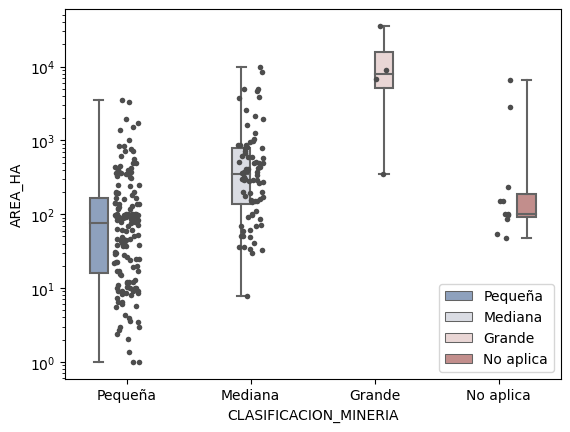

In [42]:
# Plot the orbital period with horizontal boxes
sns.boxplot(
    data, x="CLASIFICACION_MINERIA", y="AREA_HA", hue="CLASIFICACION_MINERIA",
    whis=[0, 100], width=.6, palette="vlag"
)

# Add in points to show each observation
sns.stripplot(data, x="CLASIFICACION_MINERIA", y="AREA_HA", size=4, color=".3")
plt.yscale('log')

In [43]:
gdf_final.groupby(['CLASIFICACION_MINERIA'])['AREA_HA'].agg(['min', 'mean', 'max', 'count'])

,min,mean,max,count
CLASIFICACION_MINERIA,,,,
Grande,346.8717,12882.236750,35511.1644,4
Mediana,7.8323,917.267190,9998.1130,80
No aplica,48.0500,952.863818,6596.0444,11
Pequeña,0.9980,213.607646,3573.5362,158


Text(0, 0.5, 'Area [HA]')

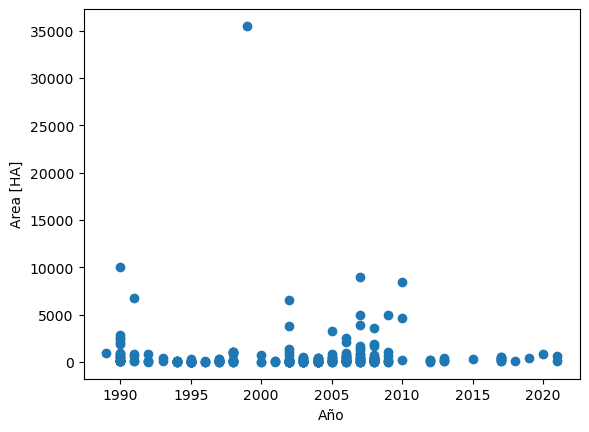

In [44]:
plt.scatter(x=data['anno_solicitud'], y=data['AREA_HA'])
#plt.yscale('log')
plt.xlabel('Año')
plt.ylabel('Area [HA]')
# No parece que las solicitudes de area hayan cambiado con el tiempo. Parece haber una discontinuidad hacia el 2000

Text(0.5, 0, 'año')

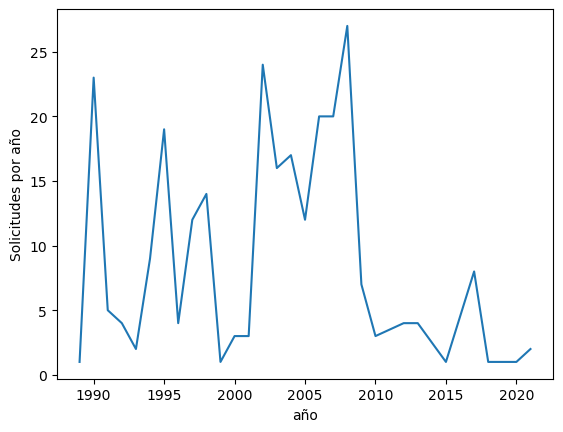

In [45]:
plt.plot(data.groupby(['anno_solicitud'])['CODIGO_EXPEDIENTE'].count().reset_index().set_index('anno_solicitud'))
plt.ylabel('Solicitudes por año')
plt.xlabel('año')
# Hacia el final del siglo y después de la gran recesión hubo un descenso de las solicitudes

<Axes: xlabel='anno_solicitud', ylabel='CODIGO_EXPEDIENTE'>

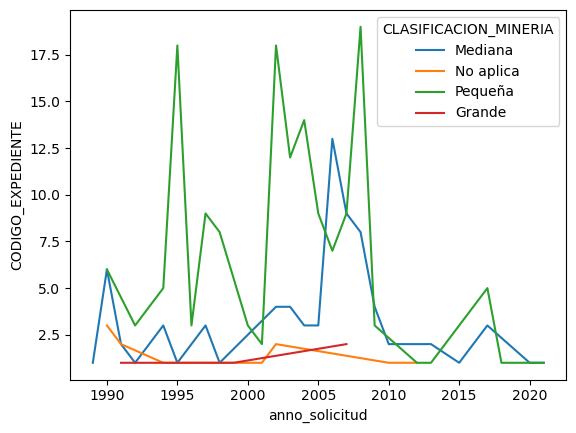

In [46]:
d = data.groupby(['anno_solicitud', 'CLASIFICACION_MINERIA'])['CODIGO_EXPEDIENTE'].count().reset_index()
sns.lineplot(data=d,
            x='anno_solicitud',
            y='CODIGO_EXPEDIENTE',
            hue='CLASIFICACION_MINERIA')
# La disminución en las solicitudes es por disminución en "Minería pequeña"

<Axes: xlabel='anno_solicitud', ylabel='AREA_HA'>

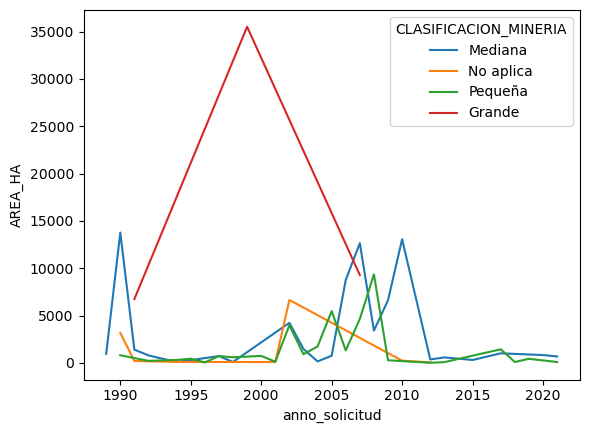

In [47]:
#d = data[data['CLASIFICACION_MINERIA'].isin(['Mediana', 'Pequeña'])]
d = data.groupby(['anno_solicitud', 'CLASIFICACION_MINERIA'])['AREA_HA'].sum().reset_index()
sns.lineplot(data=d,
            x='anno_solicitud',
            y='AREA_HA',
            hue='CLASIFICACION_MINERIA')
# El area solicitada por la minería "Grande" tiene un comportamiento claramente diferente a las demás
# Al momento de usar la variable de area solicitada es necesario distinguir entre dos categorías de 
# minería (I) Grande (II) las demás

<Axes: xlabel='anno_expedicion', ylabel='AREA_HA'>

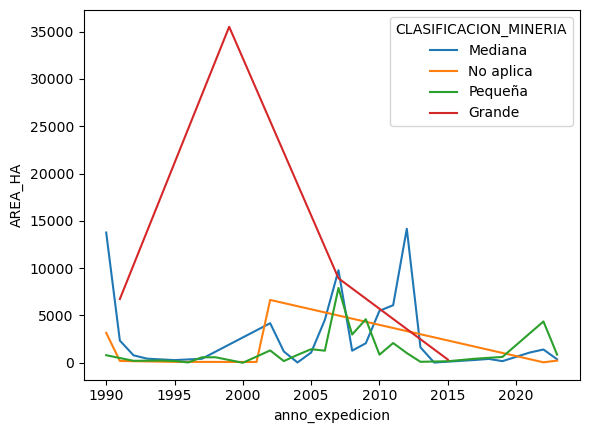

In [48]:
data['anno_expedicion'] = data['FECHA_DE_EXPEDICION'].dt.year
d = data.groupby(['anno_expedicion', 'CLASIFICACION_MINERIA'])['AREA_HA'].sum().reset_index()
sns.lineplot(data=d,
            x='anno_expedicion',
            y='AREA_HA',
            hue='CLASIFICACION_MINERIA')
# La gráfica no cambia cuando se considera la fecha de expedición en lugar de la fecha de solicitud.

<Axes: xlabel='CLASIFICACION_MINERIA', ylabel='tiempo_solicitud_expedicion'>

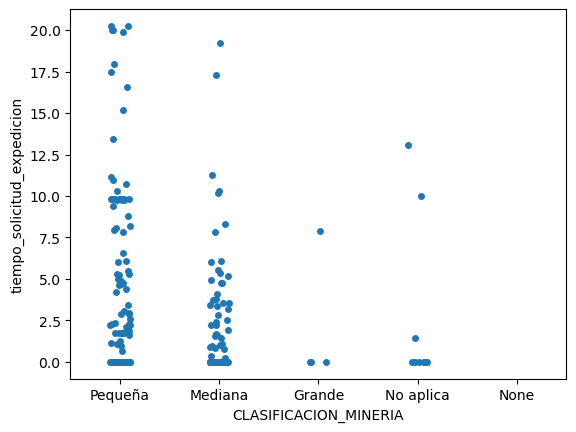

In [49]:
# Explorar si existen diferencias de tiempo entre solicitud y expedicion por tamaño de minería
data['tiempo_solicitud_expedicion'] = (data['FECHA_DE_EXPEDICION']-data['FECHA_DE_SOLICITUD']).dt.days / 365.25
sns.stripplot(data=data,
             x='CLASIFICACION_MINERIA',
             y='tiempo_solicitud_expedicion')

<Axes: xlabel='anno_solicitud', ylabel='tiempo_solicitud_expedicion'>

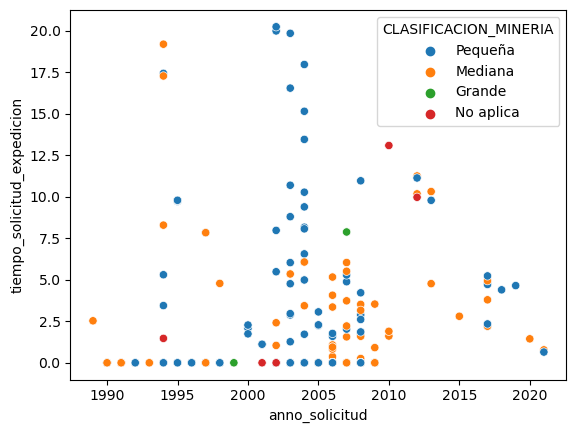

In [50]:
sns.scatterplot(data=data,
                x='anno_solicitud',
                y='tiempo_solicitud_expedicion',
               hue='CLASIFICACION_MINERIA')
#plt.yscale('log')
# Después del 2010, el tiempo entre solicitud y expedición se reduce para todos los tipos de minería

## Distinguir entre minería "Grande" y las demás

In [52]:
# Crear columna "tipo_minería" que distingue entre minería "Grande" y las demás
gdf_final['tipo_mineria'] = "Otras"
mascara = gdf_final['CLASIFICACION_MINERIA']=='Grande'
gdf_final.loc[mascara, 'tipo_mineria'] = 'Grande'

# Verificar asignaciones
gdf_final.groupby(['tipo_mineria', 'CLASIFICACION_MINERIA'])['CODIGO_EXPEDIENTE'].count().reset_index()

,tipo_mineria,CLASIFICACION_MINERIA,CODIGO_EXPEDIENTE
0,Grande,Grande,4
1,Otras,Mediana,80
2,Otras,No aplica,11
3,Otras,Pequeña,158


# Calcular areas tituladas

In [53]:
# Rutas de los archivos
ruta_municipios = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_MPIO_GRAFICO.shp'
ruta_departamentos = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_DPTO_POLITICO.shp'

# Cargar archivos
gdf_municipios = gpd.read_file(ruta_municipios)
gdf_departamentos = gpd.read_file(ruta_departamentos)

## Revisar sistemas de coordenadas

In [54]:
# Explorar Coordinate Reference System (CRS)
print('*'*20 + '\nCRS Original')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)
print('poligonos titulos mineros oro', gdf_final.crs)

# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
crs_area = "EPSG:3116"
gdf_municipios = gdf_municipios.to_crs(crs_area)
gdf_departamentos = gdf_departamentos.to_crs(crs_area)
gdf_final = gdf_final.to_crs(crs_area)

# Mostrar nuevos sistema de coordenadas
print('\n'+'*'*20 + '\nNuevo CRS')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)
print('poligonos titulos mineros oro', gdf_final.crs)

********************
CRS Original
Municipios: EPSG:4326
Departamentos: EPSG:4326
poligonos titulos mineros oro {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS_1984_Web_Mercator_Auxiliary_Sphere", "base_crs": {"name": "WGS 84", "datum": {"type": "GeodeticReferenceFrame", "name": "World Geodetic System 1984", "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": {"type": "AngularUnit", "name": "Degree", "conversion_factor": 0.0174532925199433}}, {"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": {"type": "AngularUnit", "name": "Degree", "conversion_factor": 0.0174532925199433}}]}}, "conversion": {"name": "WGS_1984_Web_Mercator_Auxiliary_Sphere", "method": {"name": "Popular Visualisation Pseudo Mercator", "id": {"authority": "EPSG", "code"

In [55]:
# Exlorar dimensión de los datos
len(gdf_final['MUNICIPIOS'].unique())

135

## Revisar si hay geometrías inválidas

In [56]:
print('*'*20 + '\nTitulos mineros')
print(f"\nVálidas:\n{gdf_final.is_valid.value_counts()}")
print(f"\nVacías: {gdf_final.is_empty.sum()}")
print(f"Totales: {gdf_final.shape[0]}")

print('\n'+'*'*20 + '\nMunicipios')
print(f"\nVálidas:\n{gdf_municipios.is_valid.value_counts()}")
print(f"\nVacías: {gdf_municipios.is_empty.sum()}")
print(f"Totales: {gdf_municipios.shape[0]}")

print('\n'+'*'*20 + '\nDepartamentos')
print(f"\nVálidas:\n{gdf_departamentos.is_valid.value_counts()}")
print(f"\nVacías: {gdf_departamentos.is_empty.sum()}")
print(f"Totales: {gdf_departamentos.shape[0]}")

********************
Titulos mineros

Válidas:
True     267
False      1
Name: count, dtype: int64

Vacías: 0
Totales: 268

********************
Municipios

Válidas:
True    1122
Name: count, dtype: int64

Vacías: 0
Totales: 1122

********************
Departamentos

Válidas:
True    33
Name: count, dtype: int64

Vacías: 0
Totales: 33


## Revisar las geometrías inválidas

,geometry,CODIGO_EXPEDIENTE,MODALIDAD,TITULO_ESTADO,AREA_HA,CLASIFICACION_MINERIA,ETAPA,SOLICITANTES_O_TITULARES,MINERALES,FECHA_DE_SOLICITUD,...,TENURE_ID,OBJECTID,MUNICIPIOS,DEPARTAMENTOS,MINERALES_INACTIVOS,TIPO_TERMINACION,TERMINATION_TYPE_CODE,ACTIVE_TENURE_STATUS_IND,ACTIVE_APPLICATION_STATUS_IND,tipo_mineria
152,"POLYGON ((930593.733 1272048.376, 930604.734 1...",R140011,RECONOCIMIENTO PROPIEDAD PRIVADA,Activo,2869.5373,No aplica,Explotación,(27399) ARIS MINING SEGOVIA,"ARENAS, ARENAS ARCILLOSAS, ARENAS FELDESPÁTICA...",1990-05-16,...,R140011,178626,"REMEDIOS, SEGOVIA",Antioquia,None,None,None,Y,N,Otras


(1270000.0, 1290000.0)

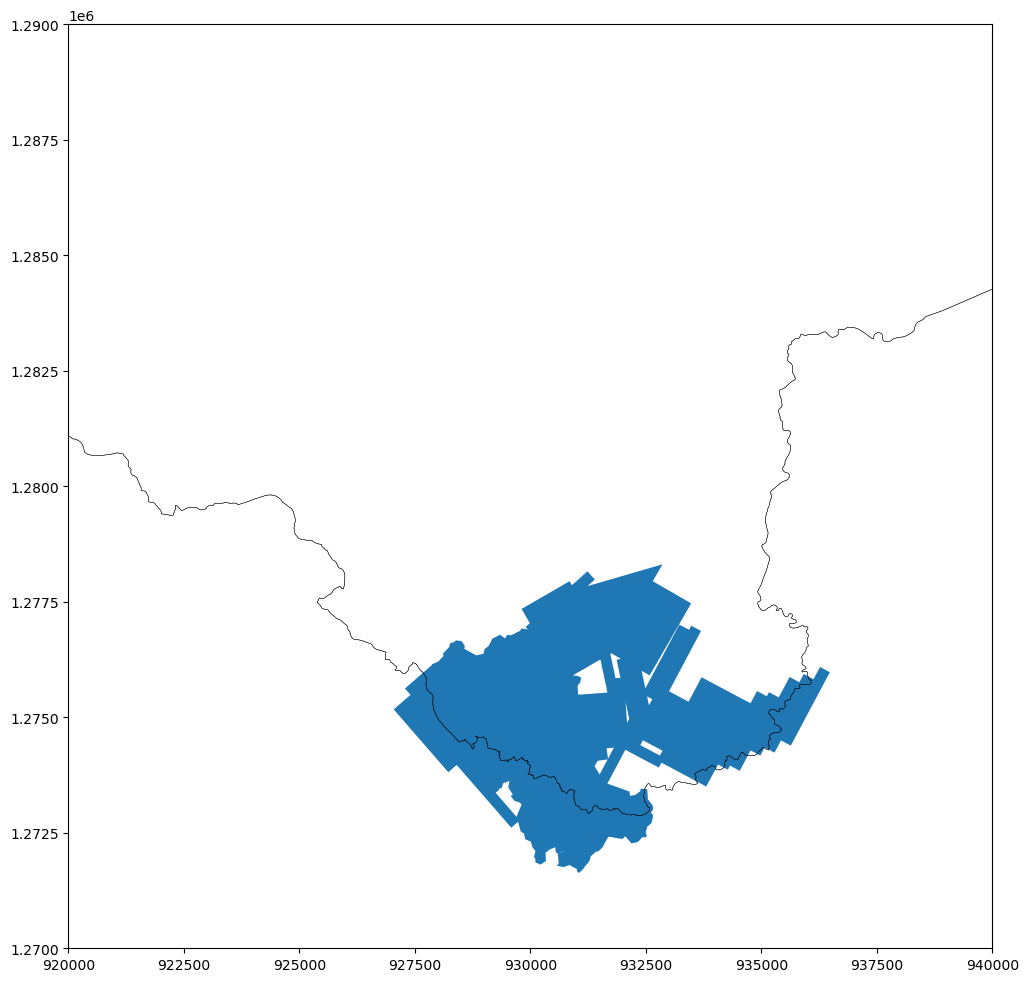

In [57]:
# Revisar las geoemtrías inválidas
invalid = gdf_final[~gdf_final.is_valid]
display(invalid.head())


# Elementos básicos de la gráfica
departamento = 'Antioquia'
departamento_mayuscula = 'ANTIOQUIA'

# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de municipios y departamentos
gdf_municipios[gdf_municipios['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos[gdf_departamentos['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=1.2, color='black')
invalid.plot(ax=ax)

# Acotar vista al polígono inválido
ax.set_xlim([0.92e6, 0.94e6])
ax.set_ylim([1.27e6, 1.29e6])

## Arreglar geometrías inválidas

In [58]:
mask = ~gdf_final.is_valid # Identificar la fila de geometría inválida
# Corregir el polígono
gdf_final.loc[mask, "geometry"] = gdf_final.loc[mask, "geometry"].apply(make_valid)

# Convertir el multipolygon que sale de make_valid en múltiples filas. Necesario para el cálculo de areas
gdf_final = gdf_final.explode(index_parts=False)

In [59]:
# Explorar dimensiones
print('*'*20 + '\nTitulos mineros')
print(f"\nVálidas:\n{gdf_final.is_valid.value_counts()}")
print(f"\nVacías: {gdf_final.is_empty.sum()}")
print(f"Totales: {gdf_final.shape[0]}")
# Antes eran 268 polígonos. 
# Como el poligono inválido se dividió en segmentos que lo representan (multipolygon),
# ahora el gdf tiene más filas, pero representa exactamente lo mismo

********************
Titulos mineros

Válidas:
True    287
Name: count, dtype: int64

Vacías: 0
Totales: 287


(1270000.0, 1290000.0)

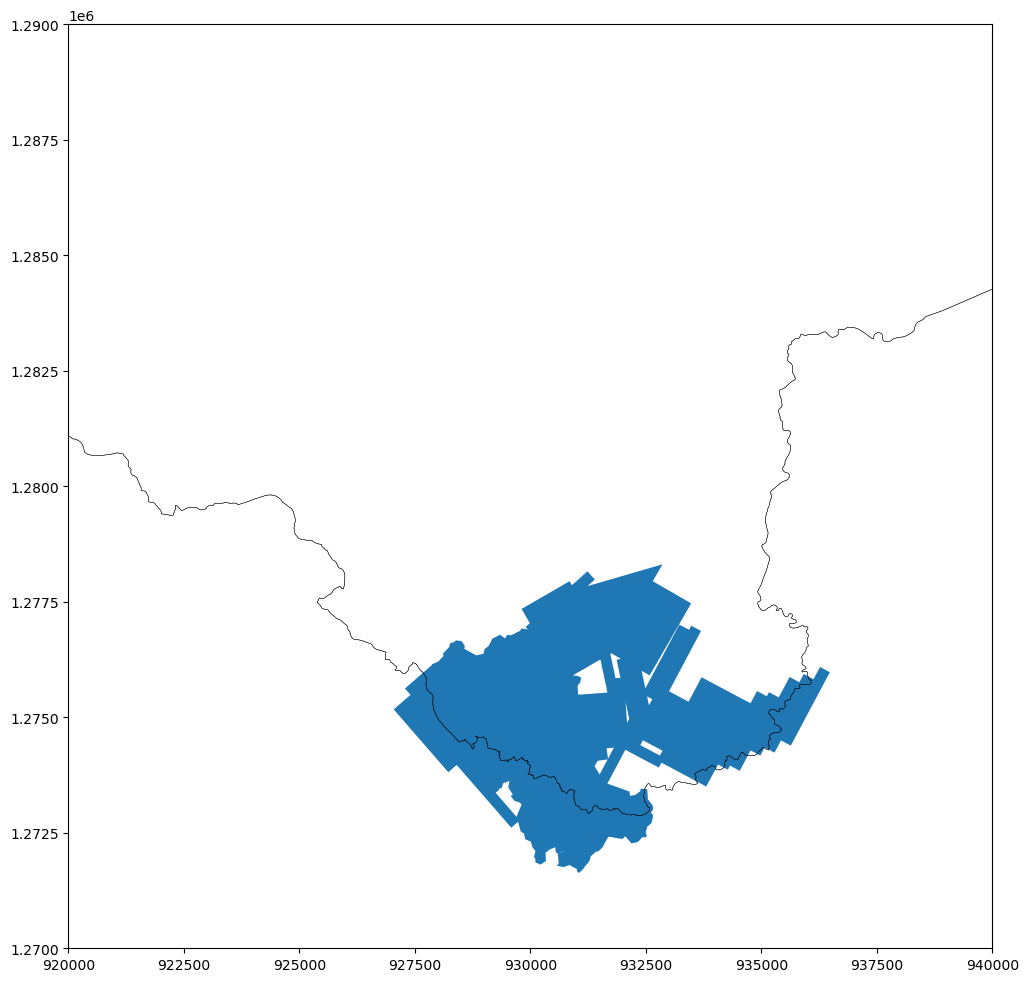

In [60]:
# Revisar la nueva geometría.
# El expediente de la geometría inválida era R140011

# Elementos básicos de la gráfica
departamento = 'Antioquia'
departamento_mayuscula = 'ANTIOQUIA'

# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de municipios y departamentos
gdf_municipios[gdf_municipios['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos[gdf_departamentos['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=1.2, color='black')
gdf_final[gdf_final['CODIGO_EXPEDIENTE']=='R140011'].plot(ax=ax)

# Acotar vista al polígono inválido
ax.set_xlim([0.92e6, 0.94e6])
ax.set_ylim([1.27e6, 1.29e6])

# Como la geometría es la misma del mapa anterior, el area no se vió afectada.
# El único cambio es que ahora la geometría se expresa de una forma válida

# Verificación visual

## Mapa Antioquia

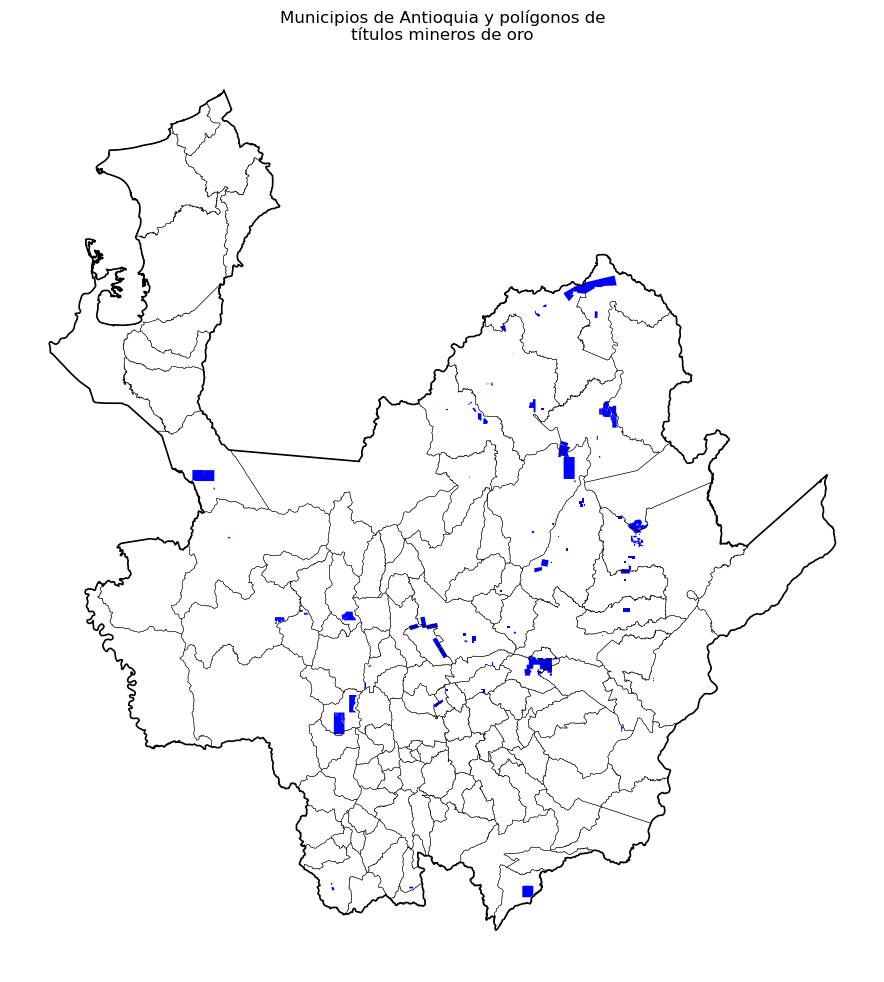

<Figure size 640x480 with 0 Axes>

In [80]:
departamento = 'Antioquia'
departamento_mayuscula = 'ANTIOQUIA'

# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))


# Contornos de municipios y departamentos
gdf_municipios[gdf_municipios['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos[gdf_departamentos['dpto_cnmbr'] == departamento_mayuscula].boundary.plot(ax=ax, linewidth=1.2, color='black')

# POligonos de titulos mineros de oro
gdf_final[gdf_final['DEPARTAMENTOS'] == departamento].plot(ax=ax, color='blue')


# Ejes
#ax.set_xlim([0.45e6, 1.81e6])
#ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica
ax.set_title("Municipios de Antioquia y polígonos de\ntítulos mineros de oro")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./outputs/M1_Antioquia_titulos_mineros.png', dpi=300)

## Mapa Colombia

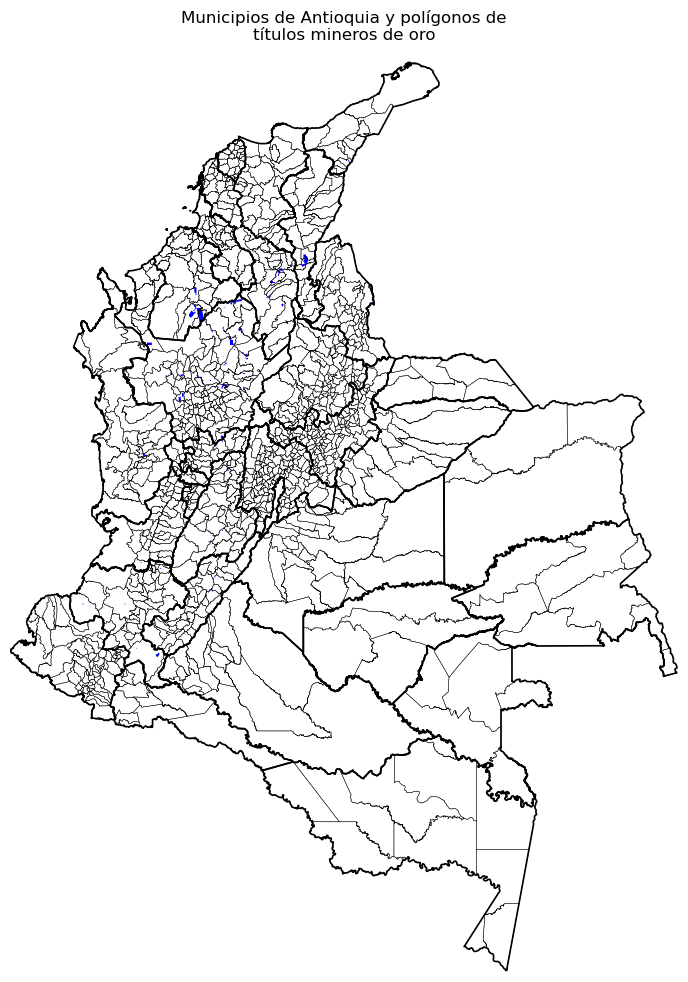

<Figure size 640x480 with 0 Axes>

In [81]:
# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))


# Contornos de municipios y departamentos
gdf_municipios.boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos.boundary.plot(ax=ax, linewidth=1.2, color='black')

# POligonos de titulos mineros de oro
gdf_final.plot(ax=ax, color='blue')


# Ejes
ax.set_xlim([0.45e6, 1.81e6])
ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica
ax.set_title("Municipios de Antioquia y polígonos de\ntítulos mineros de oro")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./outputs/M2_Colombia_titulos_mineros.png', dpi=300)

## Calculo de area con intersección de polígonos

In [61]:
# Extraer información de interés
municipios_base = gdf_municipios[['mpio_cdpmp', 'mpio_cnmbr', 'geometry']]
titulos_base = gdf_final.copy()

# Hcaer intersección de polígonos
gdf_interseccion = gpd.overlay(titulos_base, municipios_base, how='intersection')

# Explorar el resultado
print('\n'+'*'*20 + '\nShape: ', gdf_interseccion.shape)
print('\n'+'*'*20 +'\nData:')
print(gdf_interseccion.head())
print('\n'+'*'*20 +'\n\nColumnas:')
print(gdf_interseccion.columns)
print('\n'+'*'*20 +'\n\nCada polígono de un título minero pudo quedar dividido en varios municipios:')
display(gdf_interseccion.groupby('CODIGO_EXPEDIENTE')['mpio_cnmbr'].count().sort_values(ascending=False))


********************
Shape:  (376, 32)

********************
Data:
  CODIGO_EXPEDIENTE                       MODALIDAD TITULO_ESTADO     AREA_HA  \
0    ARE-SCG-08001X  CONTRATO ESPECIAL DE CONCESIÓN        Activo    497.5506   
1    ARE-SCG-08011X  CONTRATO ESPECIAL DE CONCESIÓN        Activo    176.1677   
2          G5931005   CONTRATO DE CONCESIÓN (L 685)        Activo     40.6473   
3         JDG-16061   CONTRATO DE CONCESIÓN (L 685)        Activo    427.9319   
4           L853005    CONTRATO EN VIRTUD DE APORTE        Activo  35511.1644   

  CLASIFICACION_MINERIA        ETAPA  \
0               Pequeña  Explotación   
1               Mediana  Explotación   
2               Pequeña  Explotación   
3               Mediana  Explotación   
4                Grande  Explotación   

                            SOLICITANTES_O_TITULARES  \
0  (27585) DIEGO HERNAN GIRALDO LOPEZ, (17865) IV...   
1  (27585) DIEGO HERNAN GIRALDO LOPEZ, (17865) IV...   
2                   (14517) JULIO CE

CODIGO_EXPEDIENTE
T13635011    10
L853005       7
L5682005      7
DIR-072       4
L5419005      4
             ..
FI7-161       1
FKJ-083       1
FLN-093       1
FLV-09V       1
T823005       1
Name: mpio_cnmbr, Length: 268, dtype: int64

In [62]:
# Calcular area de cada polígono
# Como ya estoy en Bogotá-Magnas-Sirgas, los cálculos de area ya salen en m^2
gdf_interseccion["area_intersectada_m2"] = gdf_interseccion.geometry.area

# Calcular el area de cada municipio
municipios_base["area_municipio_m2"] = municipios_base.geometry.area

# Anexar cálculo de area a gdf de intersección
gdf_interseccion = gdf_interseccion.merge(
    municipios_base[["mpio_cdpmp", "area_municipio_m2"]],
    on="mpio_cdpmp",
    how="left"
)

C:\Users\jcalf\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## Calcular area solicitada y expedida por municipio por año

In [63]:
# Crear variable de año
gdf_interseccion['anno_solicitud'] = gdf_interseccion['FECHA_DE_SOLICITUD'].dt.year
gdf_interseccion['anno_expedicion'] = gdf_interseccion['FECHA_DE_EXPEDICION'].dt.year
gdf_interseccion['anno_expiracion'] = gdf_interseccion['FECHA_DE_EXPIRACION'].dt.year

# Crear df con area anual solicitada y expedida por cada tipo de minería
area_anual_solicitada = gdf_interseccion.groupby(
    ['mpio_cdpmp','anno_solicitud', 'tipo_mineria'])['area_intersectada_m2'].sum().reset_index()
area_anual_expedida = gdf_interseccion.groupby(
    ['mpio_cdpmp','anno_expedicion', 'tipo_mineria'])['area_intersectada_m2'].sum().reset_index()
area_anual_expirada = gdf_interseccion.groupby(
    ['mpio_cdpmp','anno_expiracion', 'tipo_mineria'])['area_intersectada_m2'].sum().reset_index()

# Arreglar nombre de las variables en cada DF
area_anual_solicitada = area_anual_solicitada.rename(columns=
                                                     {'anno_solicitud':'anno',
                                                     'area_intersectada_m2':'area_solicitada_m2'})
area_anual_expedida = area_anual_expedida.rename(columns=
                                                 {'anno_expedicion':'anno',
                                                 'area_intersectada_m2':'area_expedida_m2'})
area_anual_expirada = area_anual_expirada.rename(columns=
                                                 {'anno_expiracion':'anno',
                                                 'area_intersectada_m2':'area_expirada_m2'})

In [64]:
# Explorar resultados

# mostrar dfs
print(f"\n{'*'*20} Area solicitada")
display(area_anual_solicitada.shape)
display(area_anual_solicitada.head(2))
print(f"\n{'*'*20} Area expedida")
display(area_anual_expedida.shape)
display(area_anual_expedida.head(2))
print(f"\n{'*'*20} Area expirada")
display(area_anual_expirada.head(2))
display(area_anual_expirada.shape)


******************** Area solicitada


(253, 4)

,mpio_cdpmp,anno,tipo_mineria,area_solicitada_m2
0,05004,1994,Otras,1.398923e+06
1,05031,1990,Otras,1.300004e+07



******************** Area expedida


(258, 4)

,mpio_cdpmp,anno,tipo_mineria,area_expedida_m2
0,05004,1994,Otras,1.398923e+06
1,05031,1990,Otras,1.300004e+07



******************** Area expirada


,mpio_cdpmp,anno,tipo_mineria,area_expirada_m2
0,05004,2013.0,Otras,1.398923e+06
1,05031,2006.0,Otras,1.000005e+06


(254, 4)

# Armar Panel

## PANEL area FLUJO

In [66]:
# Las observaciones del mismo año en el mismo municipio se suman

df_solicitada = area_anual_solicitada.groupby(
    ['mpio_cdpmp', 'anno', 'tipo_mineria'], as_index=False)['area_solicitada_m2'].sum()
df_expedida = area_anual_expedida.groupby(
    ['mpio_cdpmp', 'anno', 'tipo_mineria'], as_index=False)['area_expedida_m2'].sum()
df_expirada = area_anual_expirada.groupby(
    ['mpio_cdpmp', 'anno', 'tipo_mineria'], as_index=False)['area_expirada_m2'].sum()

# Asegurar el tipo de las variables
df_solicitada['anno'] = pd.to_numeric(df_solicitada['anno'], errors='coerce').astype('Int64')
df_solicitada['area_solicitada_m2'] = pd.to_numeric(df_solicitada['area_solicitada_m2'], errors='coerce').fillna(0)

df_expedida['anno'] = pd.to_numeric(df_expedida['anno'], errors='coerce').astype('Int64')
df_expedida['area_expedida_m2'] = pd.to_numeric(df_expedida['area_expedida_m2'], errors='coerce').fillna(0)

df_expirada['anno'] = pd.to_numeric(df_expirada['anno'], errors='coerce').astype('Int64')
df_expirada['area_expirada_m2'] = pd.to_numeric(df_expirada['area_expirada_m2'], errors='coerce').fillna(0)

# Encontrar el intervalo de tiempo
anio_min = int(min([df_solicitada['anno'].min(), df_expedida['anno'].min(), df_expirada['anno'].min()]))
anio_max = int(min([df_solicitada['anno'].max(), df_expedida['anno'].max(), df_expirada['anno'].max()]))

In [67]:
# Encontrar el dominio de cada variable para crear un panel balanceado
municipios = df_solicitada['mpio_cdpmp'].drop_duplicates().sort_values()
tipos = df_solicitada['tipo_mineria'].drop_duplicates().sort_values()
anios = pd.Index(range(anio_min, anio_max + 1), name='anno')

In [68]:
# Crear panel base
panel_base = (
    pd.MultiIndex.from_product(
        [municipios, anios, tipos],
        names=['mpio_cdpmp', 'anno', 'tipo_mineria']
    )
    .to_frame(index=False)
)

# Incorporar observaciones al panel base
panel_flujo = (
    panel_base
    .merge(df_solicitada, on=['mpio_cdpmp', 'anno', 'tipo_mineria'], how='left')
)

panel_flujo = (
    panel_flujo
    .merge(df_expedida, on=['mpio_cdpmp', 'anno', 'tipo_mineria'], how='left')
)

panel_flujo = (
    panel_flujo
    .merge(df_expirada, on=['mpio_cdpmp', 'anno', 'tipo_mineria'], how='left')
)

# En los años en que no hay registros, el flujo es 0
panel_flujo['area_solicitada_m2'] = panel_flujo['area_solicitada_m2'].fillna(0)
panel_flujo['area_expedida_m2'] = panel_flujo['area_expedida_m2'].fillna(0)
panel_flujo['area_expirada_m2'] = panel_flujo['area_expirada_m2'].fillna(0)

# calcular area titulada
panel_flujo['area_titulada_m2'] = panel_flujo['area_expedida_m2'] - panel_flujo['area_expirada_m2']

```python
# Las observaciones del mismo año en el mismo municipio se suman

df = area_anual_solicitada.groupby(
    ['mpio_cdpmp', 'anno', 'tipo_mineria'], as_index=False)['area_solicitada_m2'].sum()

# Asegurar el tipo de las variables
df['anno'] = pd.to_numeric(df['anno'], errors='coerce').astype('Int64')
df['area_solicitada_m2'] = pd.to_numeric(df['area_solicitada_m2'], errors='coerce').fillna(0)

# Encontrar el intervalo de tiempo
anio_min = int(df['anno'].min())
anio_max = int(df['anno'].max())

# Encontrar el dominio de cada variable para crear un panel balanceado
municipios = df['mpio_cdpmp'].drop_duplicates().sort_values()
tipos = df['tipo_mineria'].drop_duplicates().sort_values()
anios = pd.Index(range(anio_min, anio_max + 1), name='anno')

# Crear panel base
panel_base = (
    pd.MultiIndex.from_product(
        [municipios, anios, tipos],
        names=['mpio_cdpmp', 'anno', 'tipo_mineria']
    )
    .to_frame(index=False)
)

# Incorporar observaciones al panel base
panel_flujo = (
    panel_base
    .merge(df, on=['mpio_cdpmp', 'anno', 'tipo_mineria'], how='left')
)

# En los años en que no hay registros, el flujo es 0
panel_flujo['area_solicitada_m2'] = panel_flujo['area_solicitada_m2'].fillna(0)
```

## PANEL area STOCK

In [69]:
# Crear panel de stock a partir del panel de flujo
panel_stock = panel_flujo.copy()

panel_stock[['area_solicitada_stock_m2', 'area_titulada_stock_m2']] = (
    panel_stock
    .sort_values(['mpio_cdpmp', 'tipo_mineria', 'anno'])
    .groupby(['mpio_cdpmp', 'tipo_mineria'])[['area_solicitada_m2', 'area_titulada_m2']]
    .cumsum()
)

## Explorar datos

In [70]:
# Identificar municipios con multiples registros de area solicitada
area_anual_solicitada.groupby(['mpio_cdpmp', 'tipo_mineria'])['area_solicitada_m2'].count().unstack().reset_index().sort_values(by='Otras', ascending=False)

tipo_mineria,mpio_cdpmp,Grande,Otras
28,05604,NaN,10.0
51,13667,NaN,7.0
11,05120,1.0,7.0
34,05736,NaN,6.0
1,05031,NaN,6.0
...,...,...,...
9,05093,1.0,NaN
78,23001,1.0,NaN
80,23555,1.0,NaN
82,23682,1.0,NaN


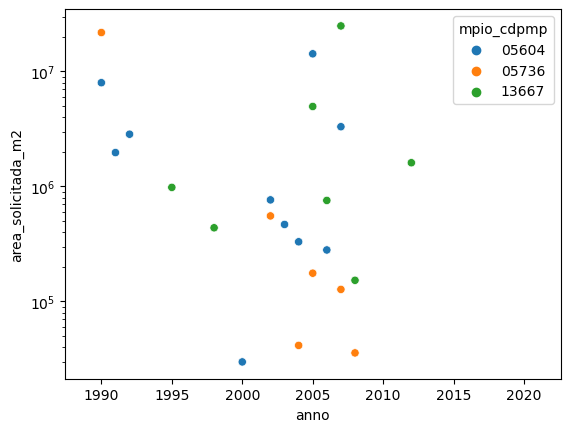

In [71]:
# Explorar municipio con varias solicitudes de area
sns.scatterplot(data=panel_flujo[panel_flujo['mpio_cdpmp'].isin(['05604', '13667', '05736'])],
               x='anno', y='area_solicitada_m2', hue='mpio_cdpmp')
plt.yscale('log')

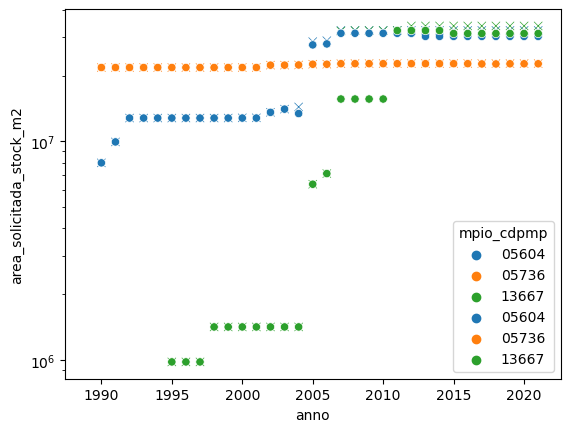

In [72]:
# Explorar municipio con varias solicitudes de area
sns.scatterplot(data=panel_stock[panel_stock['mpio_cdpmp'].isin(['05604', '13667', '05736'])],
               x='anno', y='area_solicitada_stock_m2', hue='mpio_cdpmp', marker='x')
sns.scatterplot(data=panel_stock[panel_stock['mpio_cdpmp'].isin(['05604', '13667', '05736'])],
               x='anno', y='area_titulada_stock_m2', hue='mpio_cdpmp', marker='o')
plt.yscale('log')

In [73]:
panel_stock[panel_stock['mpio_cdpmp'].isin(['05604'])]['area_titulada_m2'].min()

-1000000.8997995689

<Axes: xlabel='anno', ylabel='area_titulada_stock_m2'>

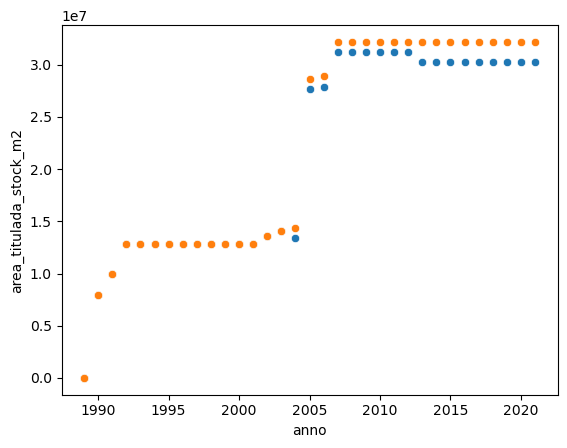

In [74]:
data=panel_stock[panel_stock['mpio_cdpmp'].isin(['05604'])]
data = data[data['tipo_mineria']=='Otras']
sns.scatterplot(data=data,
               x='anno', y='area_titulada_stock_m2', marker='o')
sns.scatterplot(data=data,
               x='anno', y='area_solicitada_stock_m2', marker='o')
# sns.scatterplot(data=data,
#                x='anno', y='area_expirada_stock_m2', marker='x')

In [78]:
panel_stock[['area_solicitada_stock_m2', 'area_titulada_stock_m2']].describe()
# Verificar que no haya ceros en las variables de Stock 
# No tiene sentido que el stock de area solicitada llegeue a negativo

,area_solicitada_stock_m2,area_titulada_stock_m2
count,8.184000e+03,8.184000e+03
mean,4.583076e+06,4.269425e+06
std,1.693486e+07,1.669681e+07
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,1.316214e+06,8.049901e+05
max,2.058466e+08,2.058466e+08


# Exportar datos

## Geodataframe de títulos mineros

In [61]:
# Exportar el area municipal con título minero
ruta_salida_mapa_municipios = './outputs/area_municipal_con_titulo_minero_oro'
area_titulada_municipio.to_parquet(ruta_salida_mapa_municipios + '.parquet')
area_titulada_municipio.to_excel(ruta_salida_mapa_municipios + '.xlsx')

# Exportar gdf de títulos mineros
gdf_final.to_parquet("./outputs/titulos_oro_validos.parquet")
gdf_final.to_excel("./outputs/titulos_oro_validos.xlsx")
gdf_final.to_file("./outputs/titulos_oro_validos.shp")

## Panel de área

In [85]:
ruta_salida_panel = "./outputs/PANEL_AREA_TITULO_MINERO_STOCK_FLUJO"
panel_stock.to_parquet(ruta_salida_panel+".parquet")
panel_stock.to_excel(ruta_salida_panel+".xlsx")

# Otros Intentos

## Calcular total de area solicitada

In [75]:
# Agregar areas titulada por municipio
area_titulada_municipio = gdf_interseccion.groupby(
    ['mpio_cdpmp', 'mpio_cnmbr'], as_index=False).agg(
    area_titulada_m2=('area_intersectada_m2', 'sum'),
    area_municipio_m2=('area_municipio_m2', 'first'))

# Explorar resultado
display(area_titulada_municipio.sort_values(by='area_titulada_m2', ascending=False))

,mpio_cdpmp,mpio_cnmbr,area_titulada_m2,area_municipio_m2
82,23682,SAN JOSÉ DE URÉ,2.058466e+08,5.256503e+08
81,23580,PUERTO LIBERTADOR,1.874616e+08,1.647519e+09
77,20550,PELAYA,1.225781e+08,4.233978e+08
3,05040,ANORÍ,6.695549e+07,1.413776e+09
5,05044,ANZÁ,6.646862e+07,2.559233e+08
...,...,...,...,...
37,05854,VALDIVIA,1.562975e+05,5.677026e+08
107,68132,CALIFORNIA,1.377010e+05,4.501346e+07
104,66045,APÍA,9.413237e+04,1.499810e+08
105,66594,QUINCHÍA,5.419712e+04,1.401430e+08
